In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("isaikumar/creditcardfraud")

print("Path to dataset files:", path)

100%|██████████| 65.9M/65.9M [00:04<00:00, 16.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/isaikumar/creditcardfraud/versions/1


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import os

df = pd.read_csv(os.path.join(path, "creditcard.csv"))
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
df.shape

(284807, 31)

In [7]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [8]:
df["Class"].value_counts()

,count
Class,
0,284315
1,492


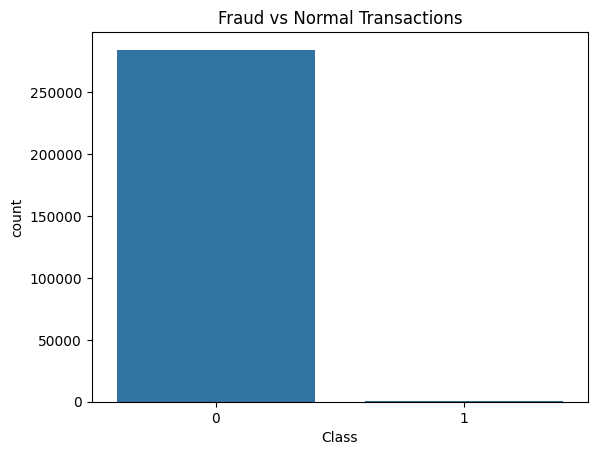

In [9]:
sns.countplot(x="Class", data=df)
plt.title("Fraud vs Normal Transactions")
plt.show()

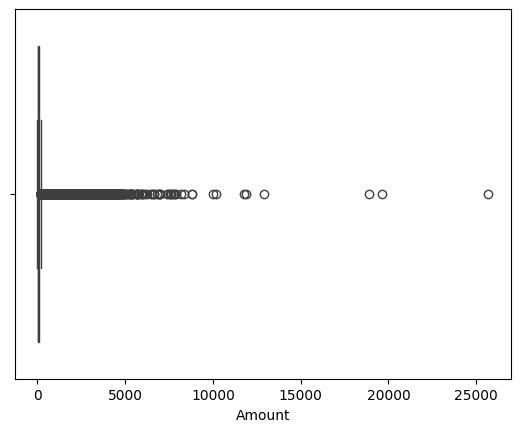

In [10]:
sns.boxplot(x=df["Amount"])
plt.show()

In [11]:
Q1 = df["Amount"].quantile(0.25)
Q3 = df["Amount"].quantile(0.75)

IQR = Q3 - Q1

df = df[(df["Amount"] >= Q1 - 1.5*IQR) &
        (df["Amount"] <= Q3 + 1.5*IQR)]

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df["Amount"] = scaler.fit_transform(df["Amount"].values.reshape(-1,1))
df["Time"] = scaler.fit_transform(df["Time"].values.reshape(-1,1))

/tmp/ipykernel_351/2943723243.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Amount"] = scaler.fit_transform(df["Amount"].values.reshape(-1,1))
/tmp/ipykernel_351/2943723243.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Time"] = scaler.fit_transform(df["Time"].values.reshape(-1,1))


In [13]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [17]:
pred = model.predict(X_test)

In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     50490
           1       0.82      0.62      0.70        91

    accuracy                           1.00     50581
   macro avg       0.91      0.81      0.85     50581
weighted avg       1.00      1.00      1.00     50581



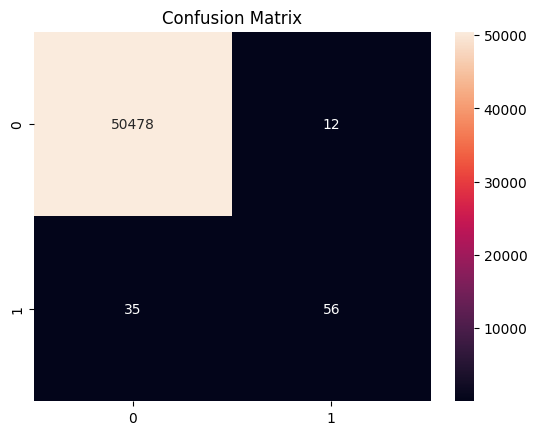

In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

In [20]:
import pickle

with open("fraud_model.pkl","wb") as f:
    pickle.dump(model,f)

In [23]:
from google.colab import files

files.download("fraud_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>